<a href="https://colab.research.google.com/github/nadiia2302/python_for_ds_tasks/blob/main/HW_11_1_Data_Visualization_using_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [73]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [74]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [75]:
df.shape

(10886, 19)

In [76]:
min_date = df['date'].min()

In [77]:
max_date = df['date'].max()

**Висновок:**

In [78]:
print("Кількість рядків у датасеті:", df.shape[0])
print(f'Дані містяться за період: {min_date} - {max_date}')

Кількість рядків у датасеті: 10886
Дані містяться за період: 2011-01-01 - 2012-12-19


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [79]:
daily_rent = df['count'].resample('D').sum()

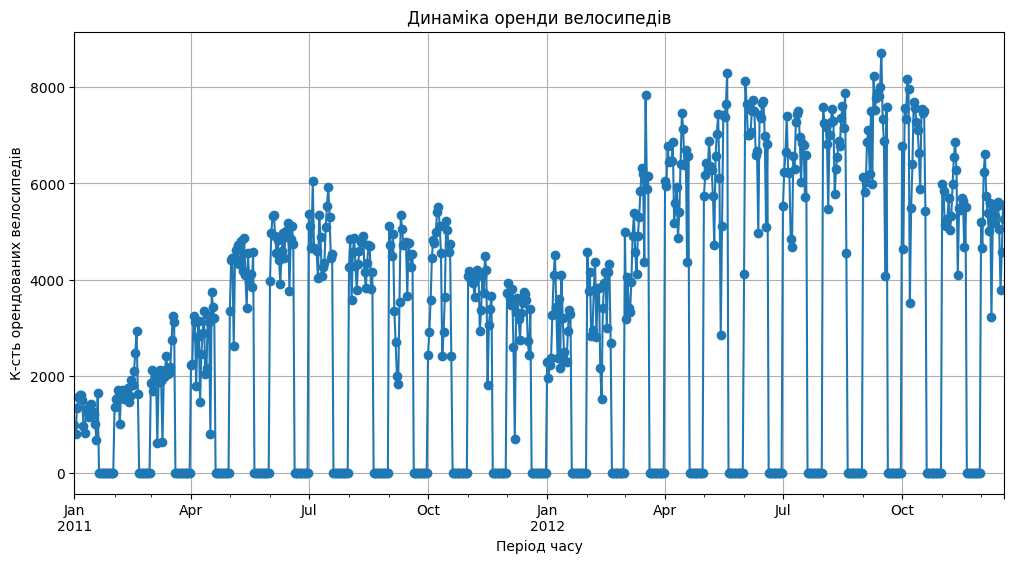

In [80]:
daily_rent.plot(
    kind = 'line',
    marker = 'o',
    figsize = (12, 6),
    title = 'Динаміка оренди велосипедів',
    grid = True,
    xlabel='Період часу',
    ylabel = 'К-сть орендованих велосипедів'
);

Питання для інтерпретації:

1)Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?

Я думаю графік має заломи, бо ми аналізуємо дані поденно, варто змінити проміжок часу, на місячний або потижневий.

2)Які загальні тенденції ви бачите на графіку?

Починаючи від березня і до жовтня у нас найбільша к-сть орендованих велосипедів. В січні і лютому найменше поїздокю. Я думаю, що це зумовленно погодою.

3)Чи помітні якісь сезонні коливання?
Так, чітко видно, що весною, влітку і восени к-сть поїздок збільшується, коли взимку - зменшується.

4)Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?

Так, січень 2011 має аномально низькі значення (зумовлено поганою погодою взимку, н-п, снігом), квітень 2012 аномально високе значення (зумовлено різким покращенням погоди після зими).



## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [81]:
import matplotlib.pyplot as plt


In [82]:
mean_rent_bicycle = df['count'].resample('QE').mean()

In [83]:
mean_rent_bicycle.head()

,count
datetime,
2011-03-31,71.905518
2011-06-30,160.940746
2011-09-30,186.994872
2011-12-31,154.787125
2012-03-31,159.476889


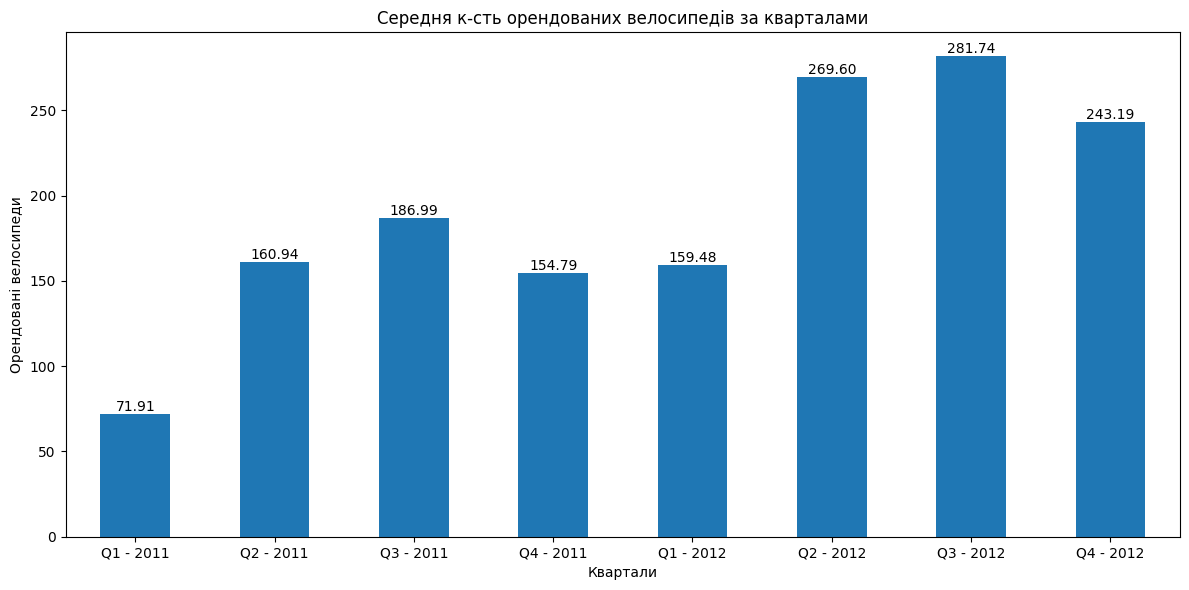

In [84]:
ax = mean_rent_bicycle.plot.bar(
    figsize = (12, 6),
    title = 'Середня к-сть орендованих велосипедів за кварталами',
    ylabel = 'Орендовані велосипеди',
    xlabel = 'Квартали'
)

labels = [f'Q{date.quarter} - {date.year}' for date in mean_rent_bicycle.index]
ax.bar_label(ax.containers[0], fmt = '%.2f')
ax.set_xticklabels(labels)
plt.xticks(rotation = 0)
plt.tight_layout()

1)В який квартал найбільша середня кількість оренди велосипедів?
Як ви можете пояснити таку сезонну закономірність?

З графіків видно, що найбільше середня кількість оренди велосипедів по 2 роках в третьому кварталі.

2)У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами?

Різниця між найпопулярнішим та найменш популярним кварталами відрізняється за 2011-2012 в 1.75 - 2.5 рази.




## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [85]:
rent_by_month = df['count'].groupby(df.index.month).mean()

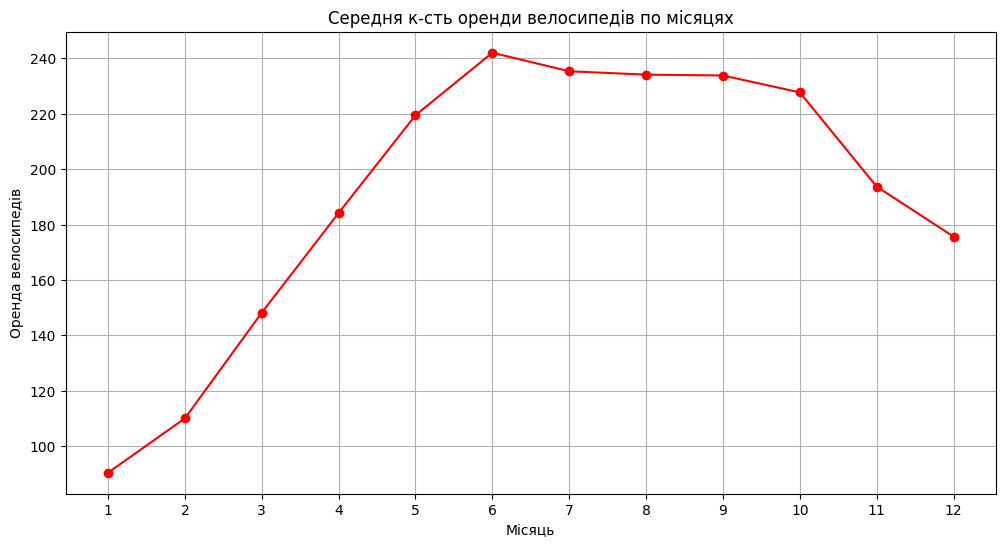

In [86]:
ax = rent_by_month.plot.line(
    figsize = (12,6),
    marker = 'o',
    color = 'red',
    grid = 'true',
    title = "Середня к-сть оренди велосипедів по місяцях",
    xlabel = "Місяць",
    ylabel = "Оренда велосипедів"
)
ax.set_xticks(range(1,13));

1)В які місяці спостерігається пік та спад оренди?

Спад оренди спостерігається з листопаду до січня включаючи. А пік оренди в червні.

2)Чи збігається ця закономірність з результатами з попереднього завдання?

Так, закономірність збігається

3)Як може вплинути клімат на оренду велосипедів протягом року?

Як бачимо, з нашого графіку, зі збільшенням теплих днів - збільшується к-сть поїздок на велосипеді. Зі зменшенням температури - зменшується к-сть поїздок.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

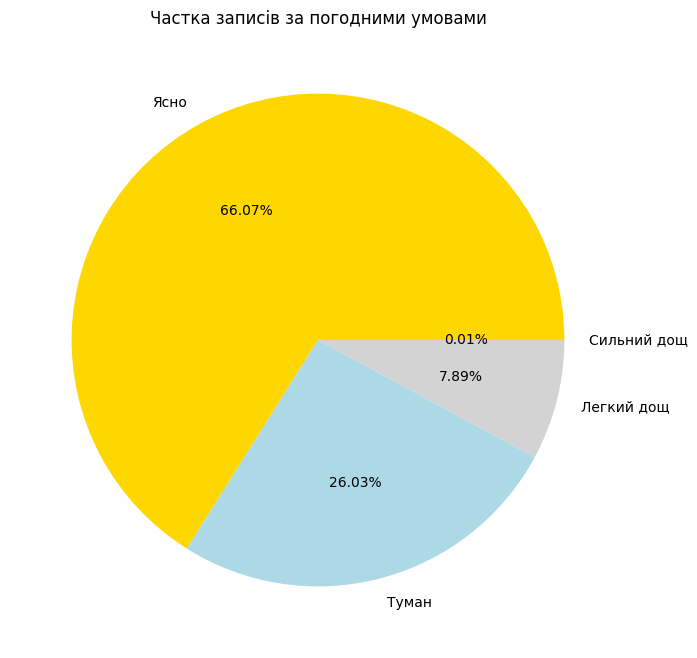

In [87]:
percentage_weather = df['weather'].value_counts()

In [88]:
percentage_weather

,count
weather,
1,7192
2,2834
3,859
4,1


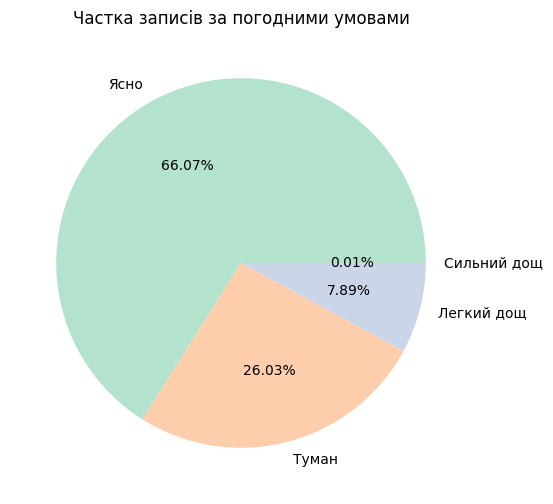

In [89]:
percentage_weather.plot.pie(
    figsize = (12,6),
    autopct = '%1.2f%%',
    labels = ['Ясно', 'Туман','Легкий дощ', 'Cильний дощ'],
    title = 'Частка записів за погодними умовами',
    ylabel ='',
    colors = plt.cm.Pastel2.colors
);

**Питання для інтерпретації:**

1.Яка погода переважає в датасеті?
В датасеті переважає ясна погода.

2.Чи є дні із сильним дощем?
Так, але їх найменше.

3.Яка їх частка?
Сильний дощ становить 0.01%

4.Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів? Я думаю, що зі збільшенням сонячних днів зростає попит на велосипеди, зі зниженням температури - зменшується попит.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [90]:
weather = ['Ясно', 'Туман','Легкий дощ', 'Cильний дощ']

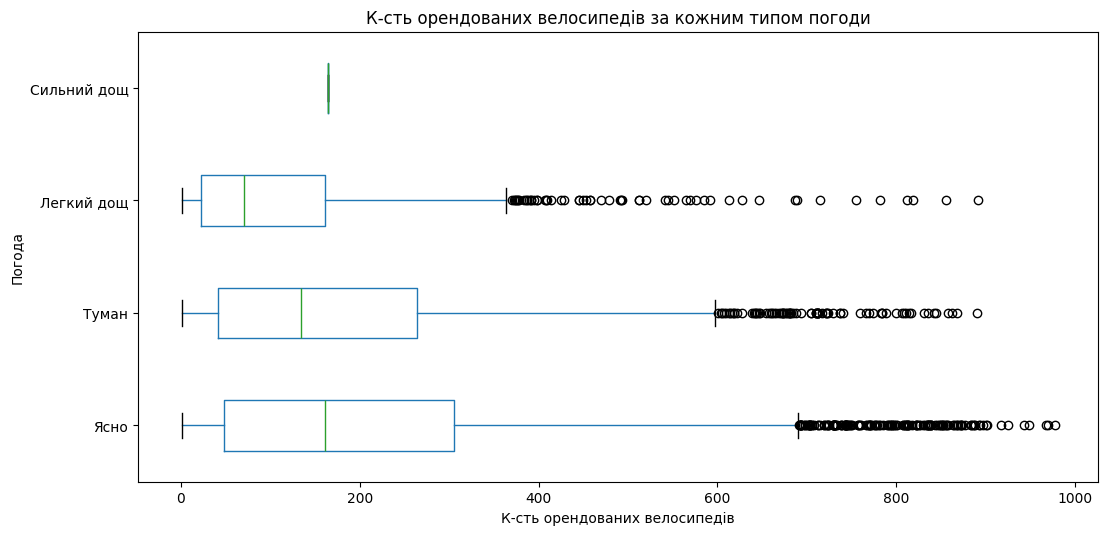

In [91]:
ax = df.boxplot(
    column='count',
    by = 'weather',
    figsize=(12,6),
    grid = False,
    vert = False
)
plt.title('К-сть орендованих велосипедів за кожним типом погоди')
plt.suptitle('')
ax.set_yticklabels(weather)
plt.ylabel('Погода')
plt.xlabel('К-сть орендованих велосипедів')
plt.show()


**Питання для інтерпретації:**

1.При якій погоді найбільший розкид у кількості оренди?
Найбільший розкид у кількості оренди підчас ясної погоди.

2.Чи є викиди (outliers) в даних? При якій погоді?
Так, викиди є підчас легкого дощу, туману та ясної погоди.

3.При якій погоді медіанне значення оренди найвище?
При ясній погоді.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

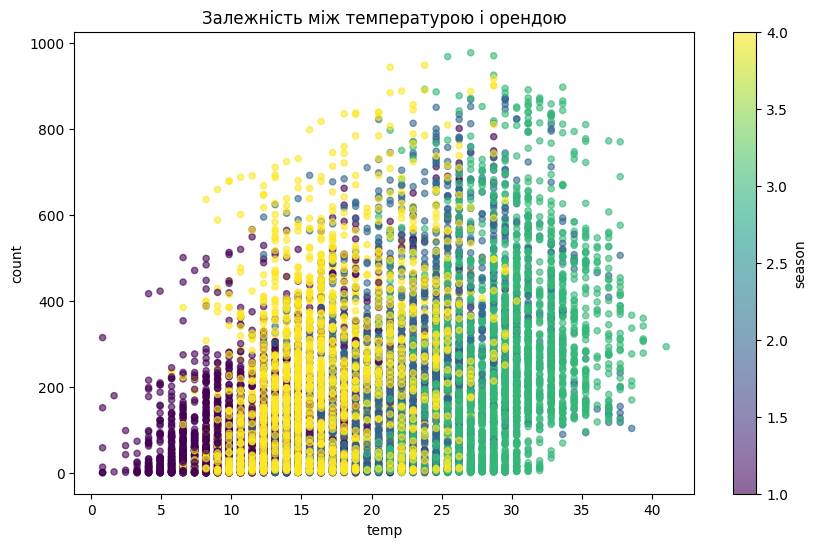

In [92]:
df.plot.scatter(
    x = 'temp',
    y = 'count',
    c = 'season',
    alpha = 0.6,
    title = 'Залежність між температурою і орендою',
    figsize = (10, 6),
    colormap = 'viridis'
  );

Чи є зв'язок між температурою та кількістю оренди? Який?
Так, є зв'язок між температурою та к-стю оренди. Позитивна кореляція.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [93]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [94]:
grouped_values = df.groupby(df.index.weekday)[['casual','registered']].mean()

In [95]:
grouped_values

,casual,registered
datetime,,
0,29.843972,160.546744
1,22.979207,166.744639
2,22.521599,165.889749
3,24.007083,173.289118
4,31.001962,166.842381
5,63.625000,133.040404
6,57.051298,123.788474


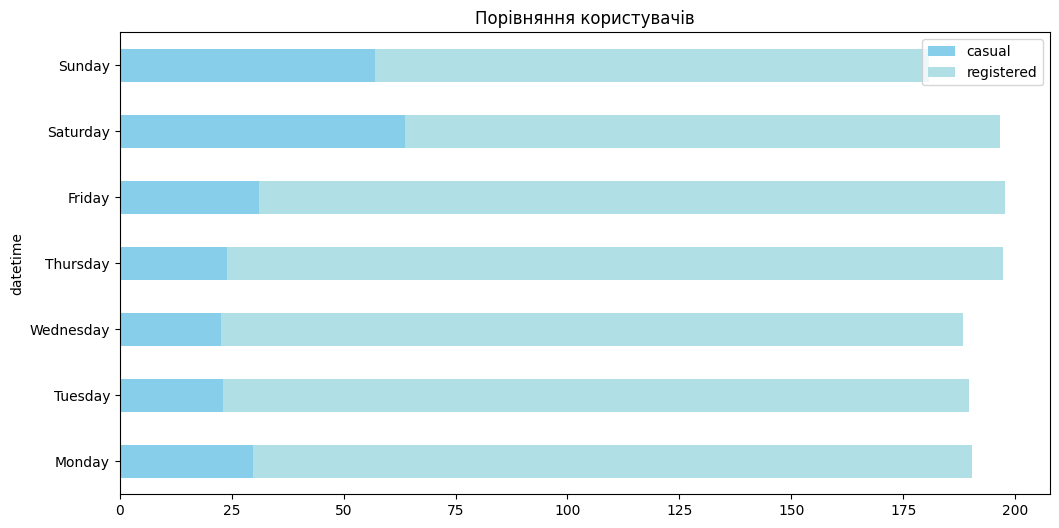

In [96]:
order_dayweek = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ax = grouped_values.plot.barh(
    figsize = (12, 6),
    color = ['skyblue', 'powderblue'],
    stacked = True,
    title = ('Порівняння користувачів')
)
ax.set_yticklabels(order_dayweek)
plt.show()




**Питання для інтерпретації:**

1.В які дні тижня більше оренд від зареєстрованих користувачів?
У четвер та п'ятницю найбільше оренд від зареєстрованих користувачів.

2.Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?
Я думаю, що у четвер і п'ятницю зареєстровані користувачі використовують оренду як засіб, щоб дістатися до роботи, а не для дозвілля. Для випадкових користувачів к-сть орендованих велосипедів зростає у Суботу та Неділю, це зумовлено тим, що вони приїжджають як туристи та користуються для відпочинку та прогулянок у вільний час.

